# Plasmadiagnostik mit Langmuir-Sonden

In [23]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as const
from scipy.optimize import least_squares
import os
from scipy.signal import savgol_filter
from math import gamma

In [24]:
def linear_res(coeff, x, y):
    a, b = coeff
    return y - (a*x+b)

def linear(coeff, x):
    a, b = coeff
    return a*x+b

def derive(x, y, step=1):
    x, y = list(x), list(y)
    x_new, y_new, x_shifted = [], [], []
    for i, val in enumerate(x):
        if i%step == 0:
            x_new.append(val)
    for i, val in enumerate(y):
        if i % step == 0:
            y_new.append(val)
    x_new = np.array(x_new)
    y_new = np.array(y_new)
    der = np.insert(np.diff(y_new)/np.diff(x_new), 0, np.nan)
    for i in range(len((x_new))):
        x_shifted.append(x_new[i] - (abs(x_new[i]-x_new[i-1])/2))
    return x_shifted, der

## Bestimmen des Plasmapotentials für alle (Sonden-) Kennlinien

Mögliche Methoden zur Bestimmung:
 1. Wendepunkt der Kennlinie: Maximum von $\frac{\mathrm{d}I_e(U)}{\mathrm{d}U}$
 2. Schnittpunkt der Geraden im $\ln (I_e)$ gegen $U$ plot

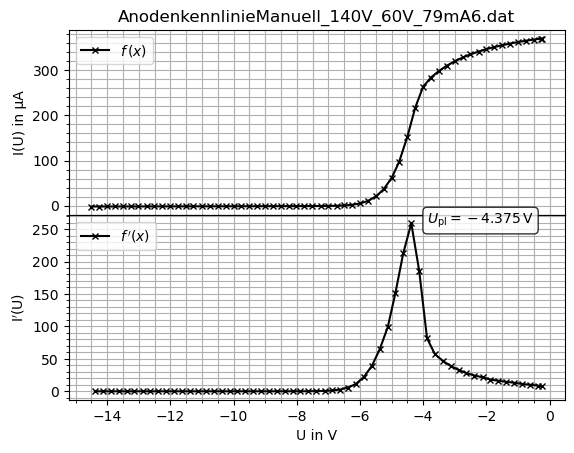

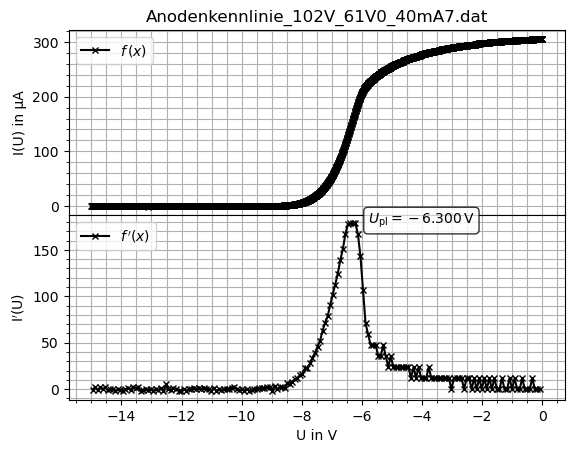

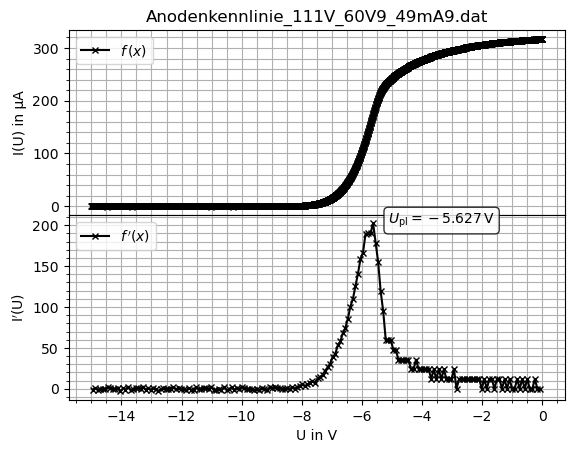

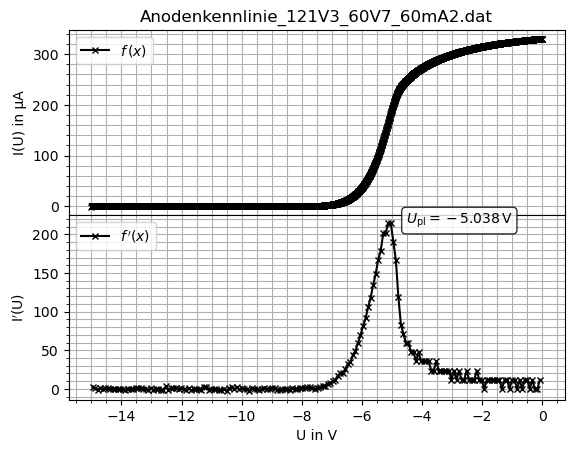

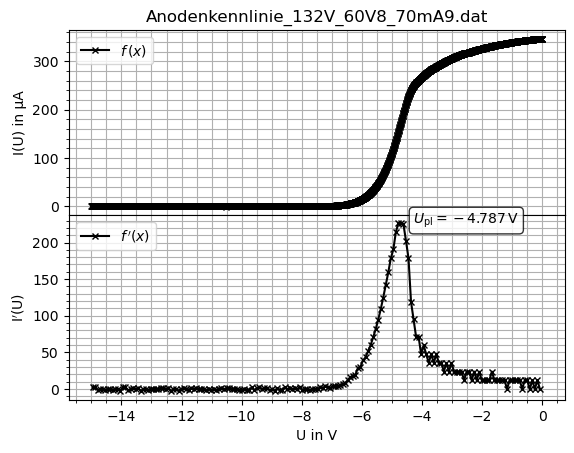

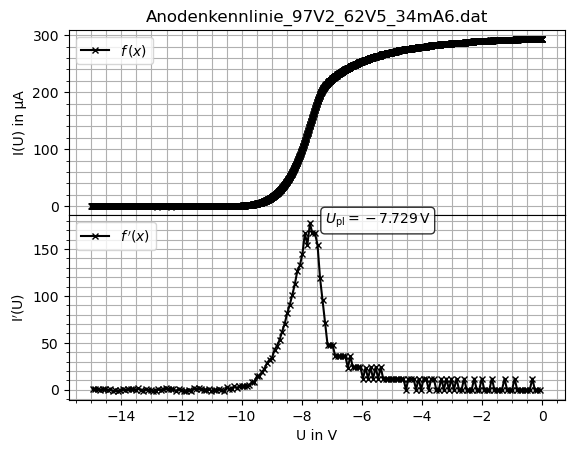

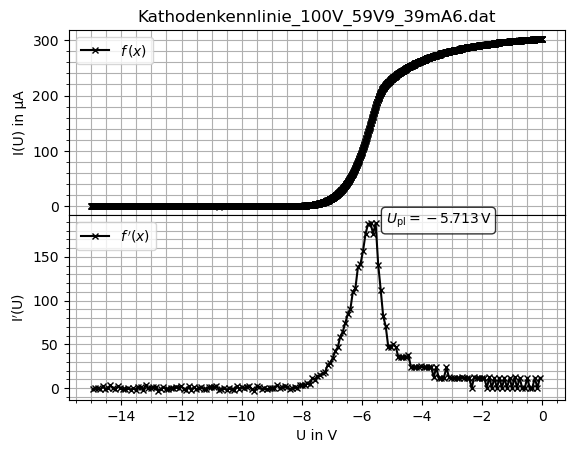

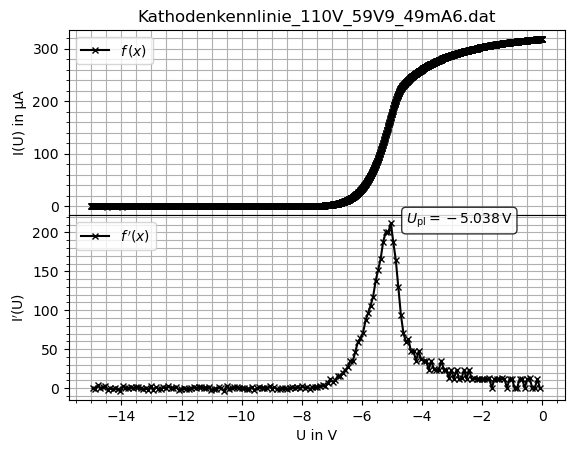

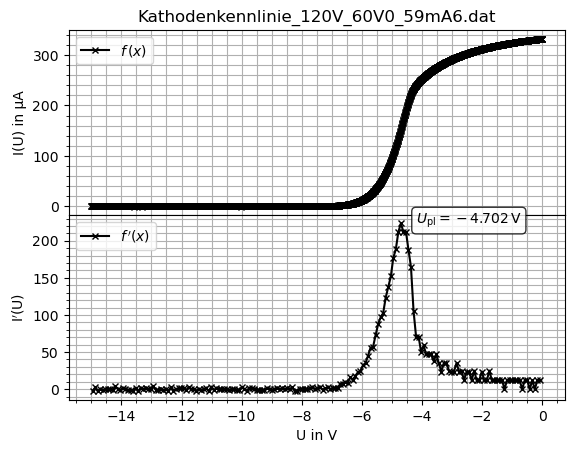

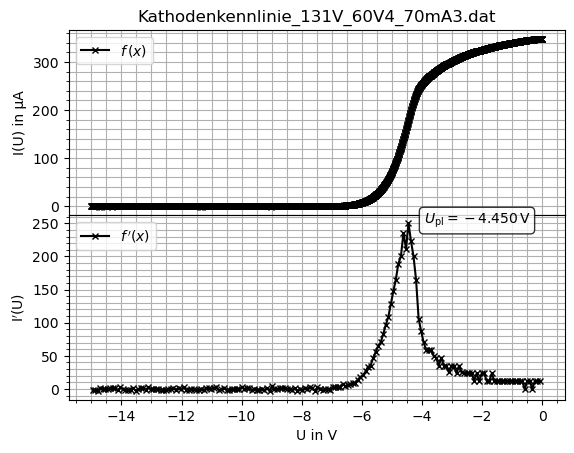

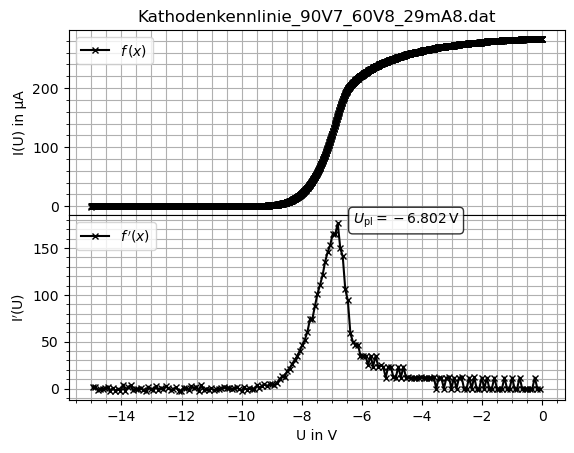

In [25]:
# Methode 1

for file in os.listdir(r'../Messdaten/17112025_Langmuirsonden/'):
    if file[-2] == 'x':
        pass
    elif len(file.split('_')) == 4: # Nur Anoden und Kathodenkennlinie ohne HHS
        data = np.loadtxt(f'../Messdaten/17112025_Langmuirsonden/{file}', delimiter = '\t', skiprows=3)
        U = data[:,0]
        I = data[:,1]*1e6 # in µA
        if file.split('_')[0] == 'Kathodenkennlinie':
            U = U - max(U)
        # Ableiten der Kennlinie funktioniert für die automatischen nur mit größeren Steigungsdreiecken
        if file.split('_')[0] == 'AnodenkennlinieManuell':
            dU, dIdU = derive(U, I, step=1)
        else:
            dU, dIdU = derive(U, I, step=14)
        imaxI = np.argmax(dIdU[1:])+1
        Upl = dU[imaxI]
        # plotten
        fig, (ax1, ax2) = plt.subplots(2,1,sharex=True, gridspec_kw={'hspace':0.0}) #layout='constrained')
        ax1.plot(U, I, 'x-k', ms=4, label=r'$f\,(x)$')
        ax2.plot(dU, dIdU, 'x-k', ms=4, label=r"$f\,^\prime (x)$")
        ax2.set_xlabel('U in V')
        ax2.set_ylabel(r"I$'$(U)")
        ax1.set_ylabel('I(U) in µA')
        ax1.set_title(file)
        ax1.legend(loc=2)
        ax1.grid(which='both')
        ax2.legend(loc=2)
        ax2.grid(which='both')
        ax1.minorticks_on()
        ax2.minorticks_on()
        ax2.text(Upl+0.5, dIdU[imaxI], r'$U_\mathrm{pl}= %4.3f \,$V' %Upl, fontsize=10, bbox={'boxstyle':'round', 'alpha':0.8, 'fc':'white', 'ec':'black'})
        # optional speichern
        figname = file.split('.')[0]
        #plt.savefig(f'../Messdaten/17112025_Langmuirsonden/Bilder/{figname}.png')
        plt.show()

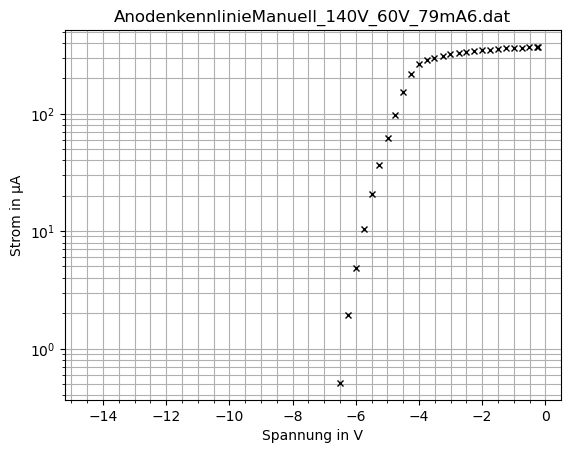

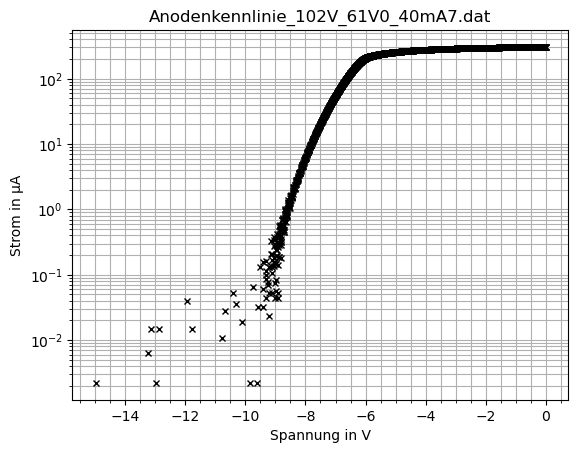

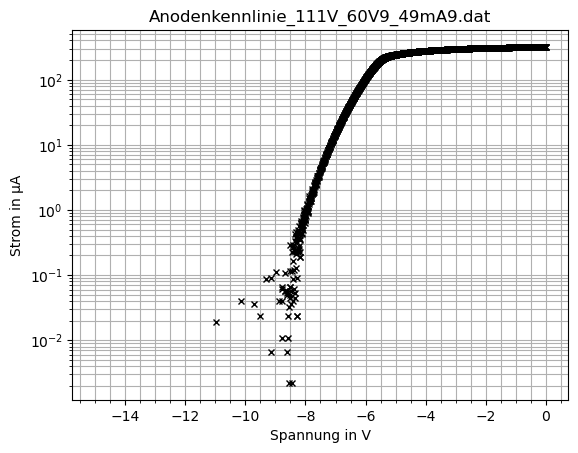

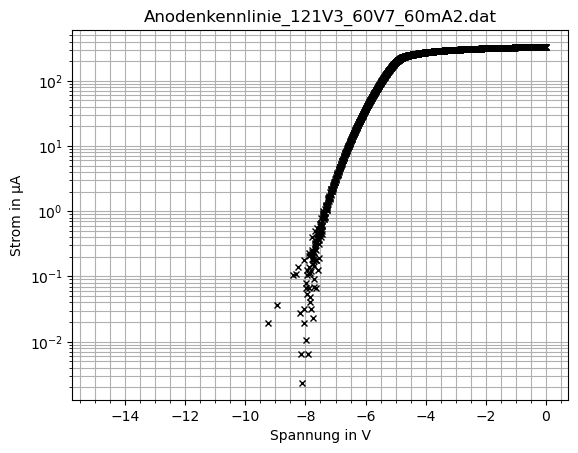

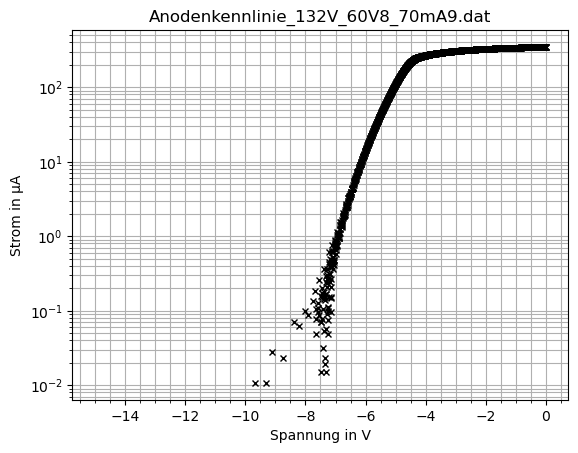

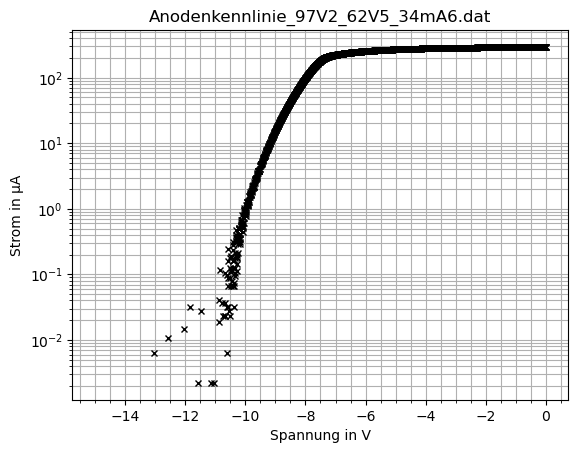

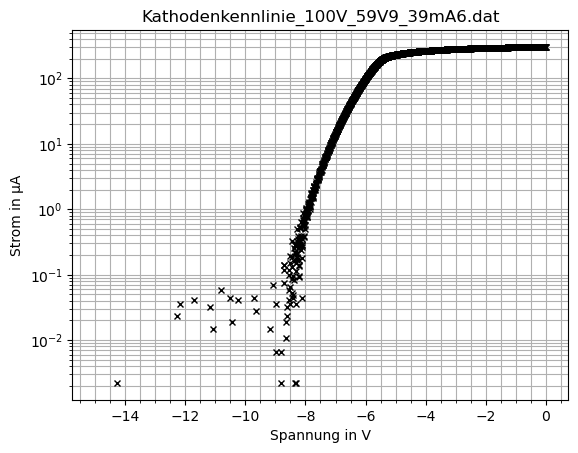

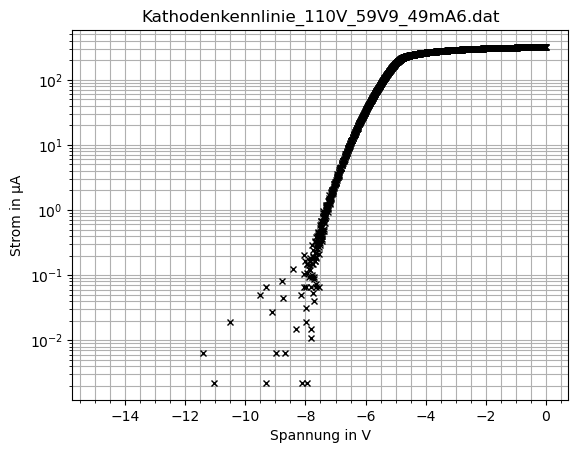

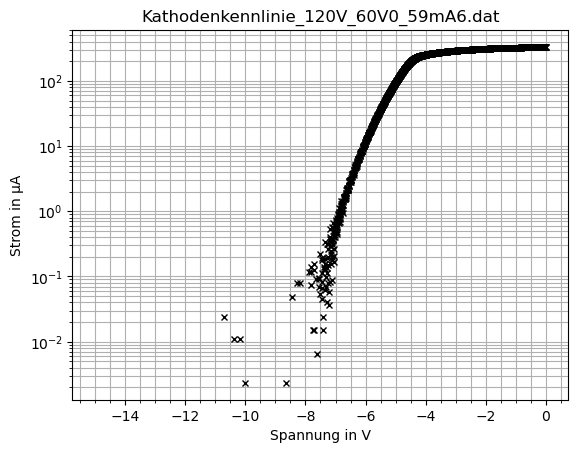

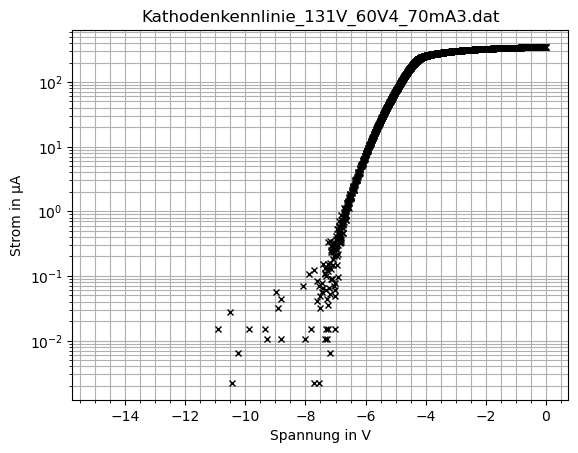

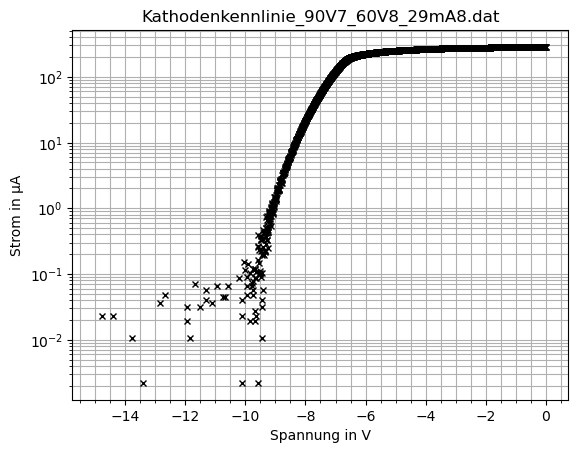

In [26]:
# Methode 2


for file in os.listdir(r'../Messdaten/17112025_Langmuirsonden/'):
    if file[-2] == 'x':
        pass
    elif len(file.split('_')) == 4: # Nur Anoden und Kathodenkennlinie ohne HHS
        data = np.loadtxt(f'../Messdaten/17112025_Langmuirsonden/{file}', delimiter = '\t', skiprows=3)
        U = data[:,0]
        I = data[:,1]*1e6 # in µA
        if file.split('_')[0] == 'Kathodenkennlinie':
            U = U - max(U)
        # plotten
        fig, ax = plt.subplots()
        ax.plot(U, I, 'xk', ms=4)
        ax.set_xlabel('Spannung in V')
        ax.set_ylabel('Strom in µA')
        ax.set_title(file)
        ax.set_yscale('log')
        ax.minorticks_on()
        plt.grid(which = 'both')
        # optional speichern
        figname = file.split('.')[0]
        #plt.savefig(f'../Messdaten/17112025_Langmuirsonden/Bilder/{figname}_logplot.png')
        plt.show()

## Bestimmen des Floating-Potential und Elektronentemperatur
Floating-Potential ist der Nulldurchgang $I(U_\mathrm{float})=0$.  
Für den Elektronstrom im Elektronenanlaufbereich gilt: $$I_\mathrm{e}(U)=-\frac{1}{4}en_eA\sqrt{\frac{8k_BT_e}{\pi m_e}}\exp\left(\frac{e(U-U_{pl})}{k_BT_e} \right).$$

Dies lässt sich umformen zu $$\ln\left(\frac{I_e(U)}{1\,mA}\right)\propto\frac{eU}{k_BT_e}.$$
Aus der Steigung im halblogarithmisch geplotteten Elektronenanlaufbereich lässt sich also die Elektronentemperatur bestimmen. Dies sei Methode 1.

Methode 2 ist eine weitere Gleichung $$k_BT_e=\frac{e}{\ln\sqrt{\frac{\exp 1}{2\pi}\frac{m_i}{m_e}}}(U_{pl}-U_{float}).$$

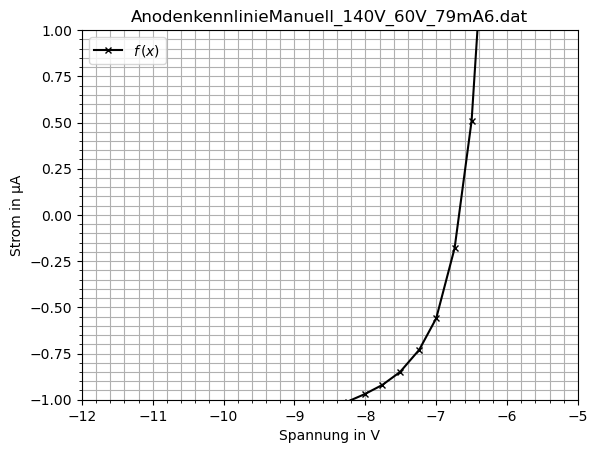

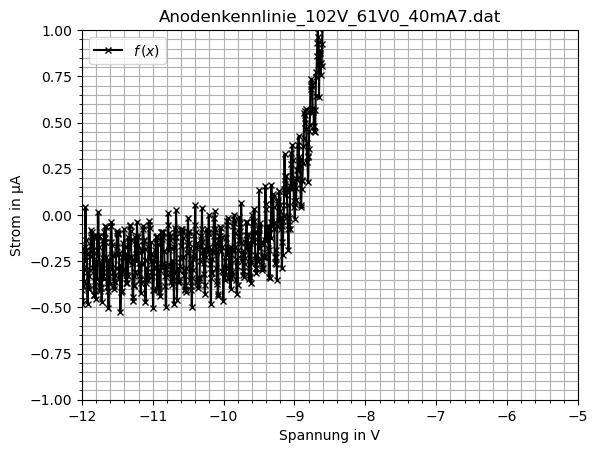

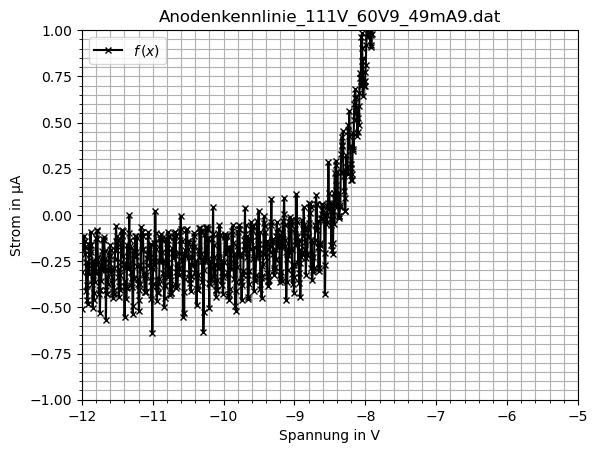

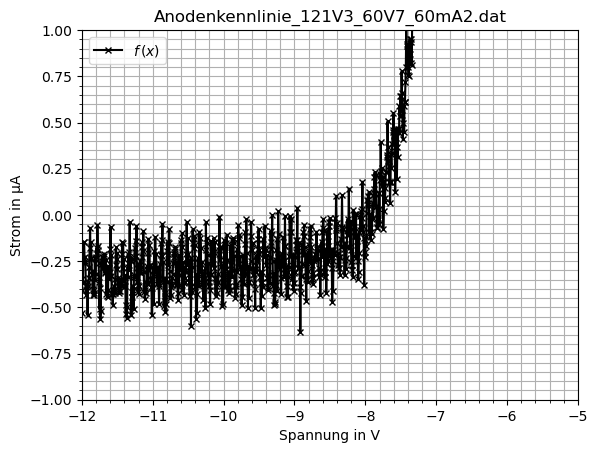

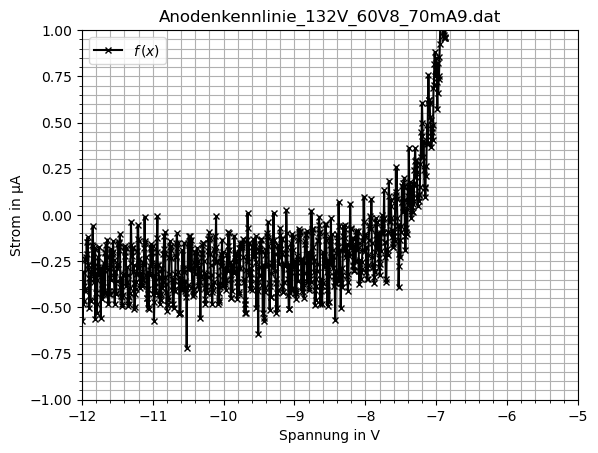

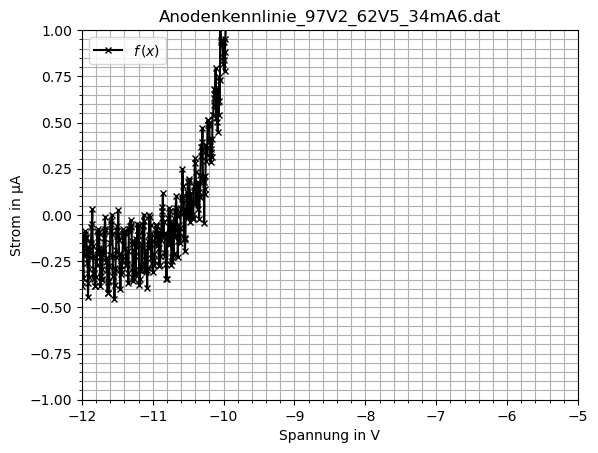

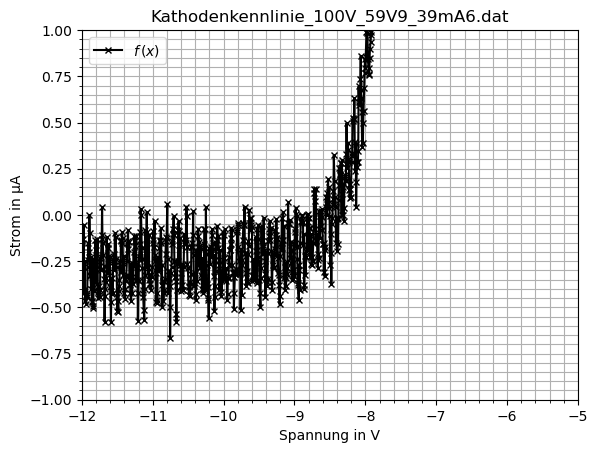

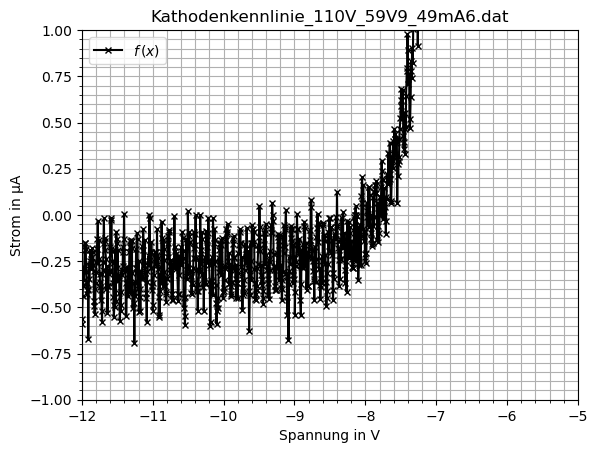

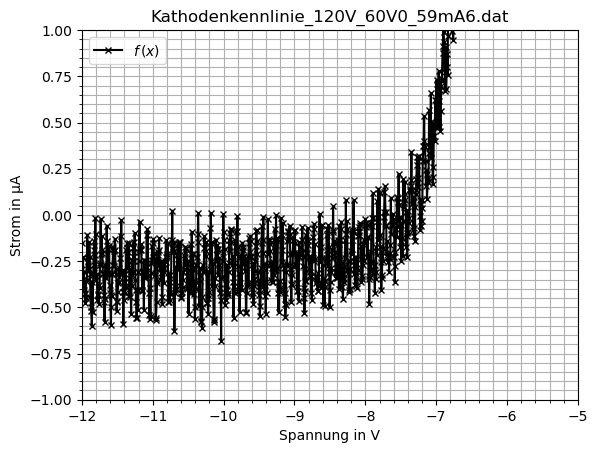

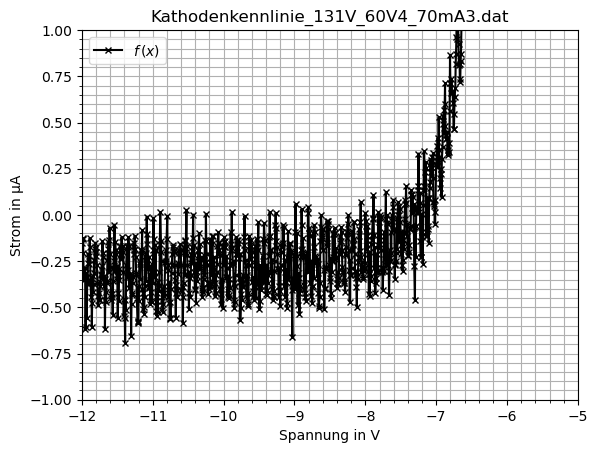

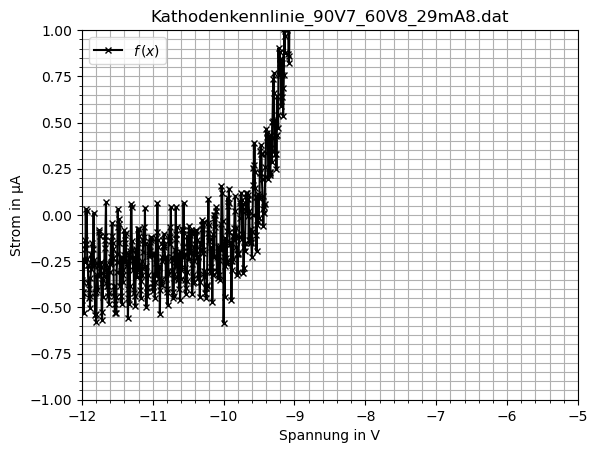

In [17]:
# gezoomte lnI U plots
for file in os.listdir(r'../Messdaten/17112025_Langmuirsonden/'):
    if file[-2] == 'x':
        pass
    elif len(file.split('_')) == 4: # Nur Anoden und Kathodenkennlinie ohne HHS
        data = np.loadtxt(f'../Messdaten/17112025_Langmuirsonden/{file}', delimiter = '\t', skiprows=3)
        U = data[:,0]
        I = data[:,1]*1e6 # in µA
        if file.split('_')[0] == 'Kathodenkennlinie':
            U = U - max(U)
        # plotten
        fig, ax1 = plt.subplots()
        ax1.plot(U, I, 'x-k', ms=4, label=r'$f\,(x)$')
        ax1.set_xlabel('Spannung in V')
        ax1.set_ylabel('Strom in µA')
        ax1.set_title(file)
        ax1.legend(loc=2)
        ax1.grid(which='both')
        ax1.minorticks_on()
        ax1.set_ylim(-1, 1) # reinzoomen um Nulldurchgang abzulesen
        ax1.set_xlim(-12,-5)
        # optional speichern
        figname = file.split('.')[0]
        #plt.savefig(f'../Messdaten/17112025_Langmuirsonden/Bilder/{figname}_zoom_Nulldurchgang.png')
        plt.show()

In [18]:
# Nulldurchgang dict
Ufl = {'140V' : -6.7, # manuelle Kennlinie
       '102V' : -9.2, # Anodenkennlinien
       '111V' : -9.5,
       '121V3': -7.8,
       '132V' : -7.5,
       '97V2' : -10.5,
       '90V7' : -9.6, # Kathodenkennlinien
       '100V' : -8.5,
       '110V' : -7.9,
       '120V' : -7.5,
       '131V' : -7.4
      } # in V

In [19]:
# Methode 1 Steigungsdreieck in halblog plot ablesen
Steigung = {'140V' : 264.66666667, # manuelle Kennlinie
            '102V' : 79.984, # Anodenkennlinien
            '111V' : 91.92,
            '121V3': 199.75,
            '132V' : 164.7,
            '97V2' : 114.27428571,
            '90V7' : 64.425, # Kathodenkennlinien
            '100V' : 119.92,
            '110V' : 124.75,
            '120V' : 74.875,
            '131V' : 99.85
            } # in µA/V

Te = const.e/np.array(list(Steigung.values()), dtype=float)/const.k
print(f'Elektronentemperatur: {Te.mean()} K')

Elektronentemperatur: 107.85461333136658 K


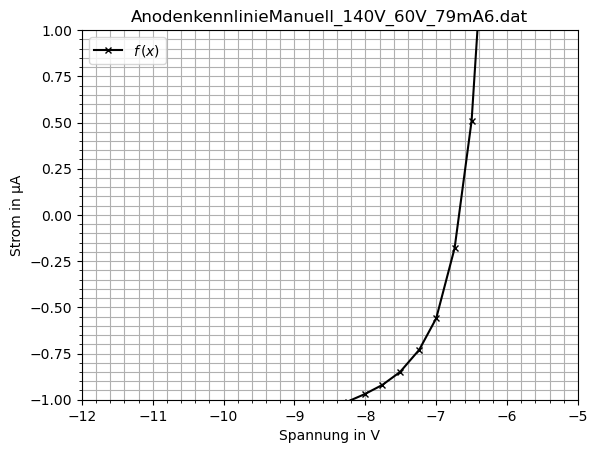

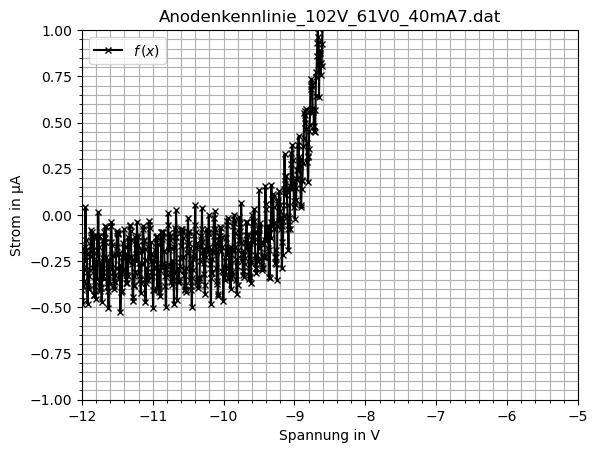

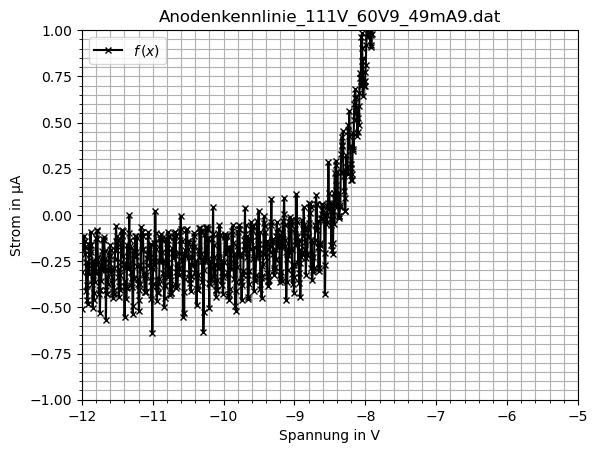

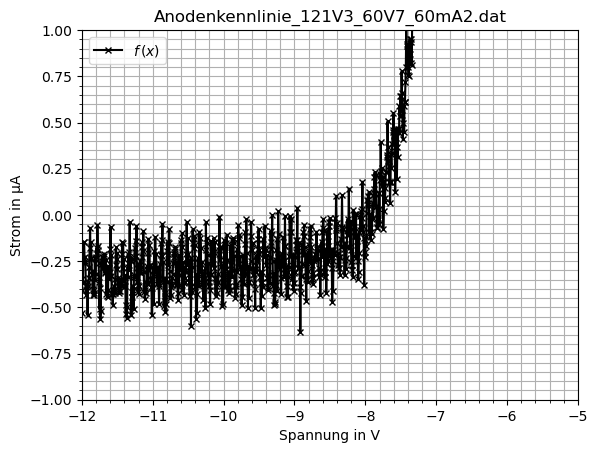

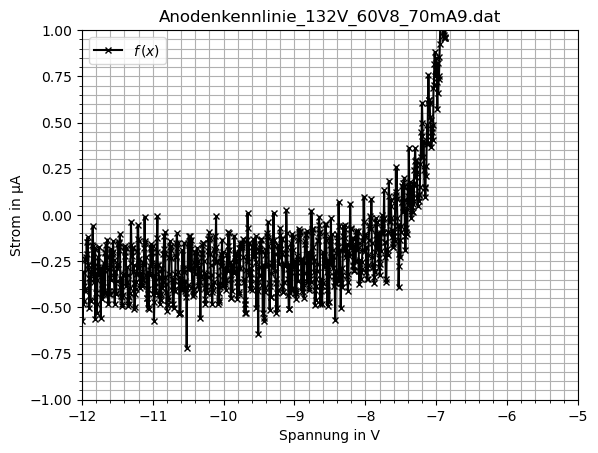

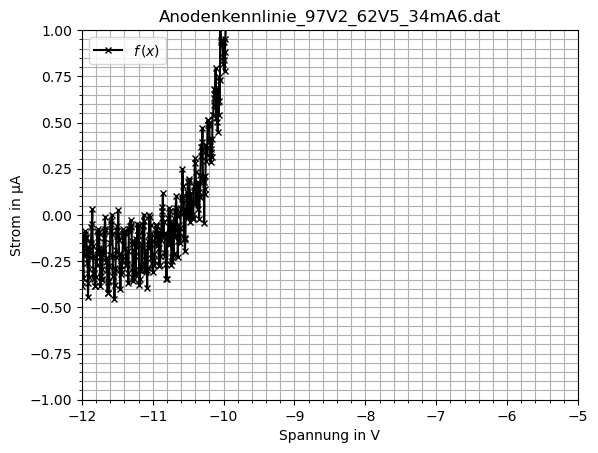

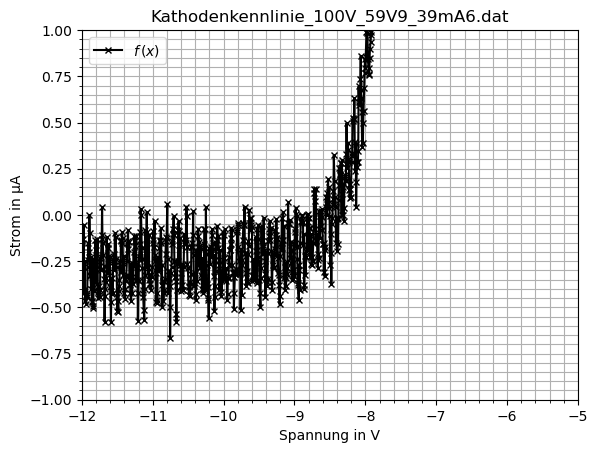

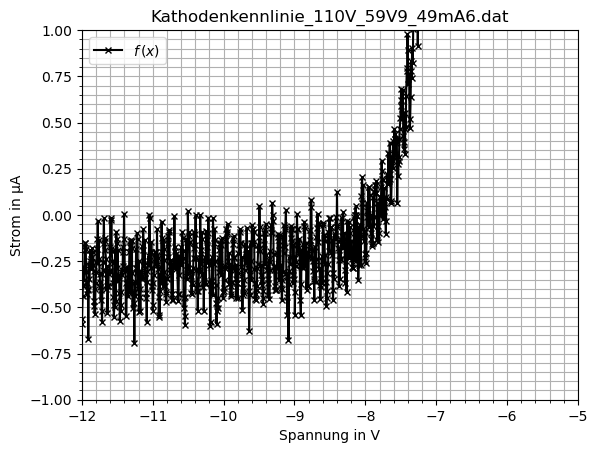

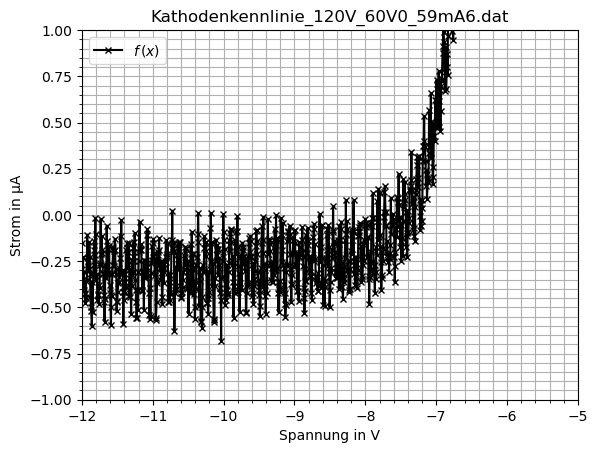

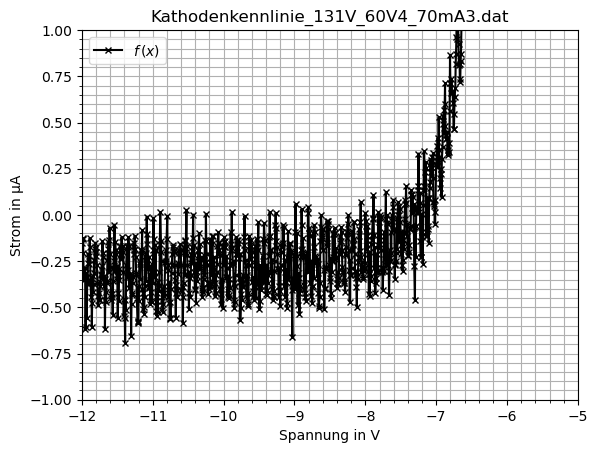

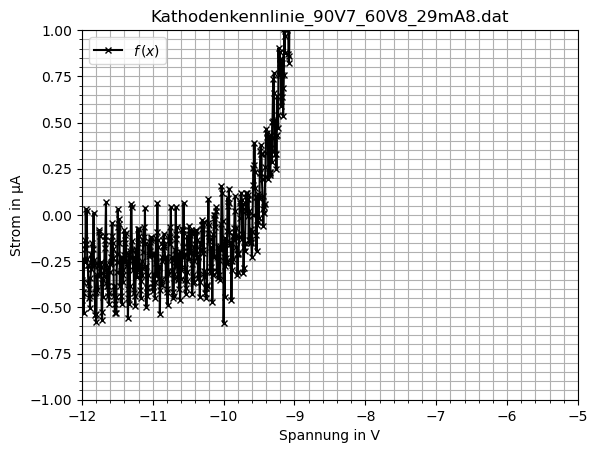

In [20]:
# Methode 1 linear Fit im halb-ln plot
for file in os.listdir(r'../Messdaten/17112025_Langmuirsonden/'):
    if file[-2] == 'x':
        pass
    elif len(file.split('_')) == 4: # Nur Anoden und Kathodenkennlinie ohne HHS
        data = np.loadtxt(f'../Messdaten/17112025_Langmuirsonden/{file}', delimiter = '\t', skiprows=3)
        U = data[:,0]
        I = data[:,1]*1e6 # in µA
        if file.split('_')[0] == 'Kathodenkennlinie':
            U = U - max(U)
        # Upl als obere Grenze für Fit bestimmen
        if file.split('_')[0] == 'AnodenkennlinieManuell':
            dU = U
            dIdU = np.insert(np.diff(I)/np.diff(U), 0, np.nan)
        else:
            dU, dIdU = derive(U, I, step=14)
        imaxI = np.argmax(dIdU[1:])+1
        Upl = dU[imaxI]
        # plotten
        fig, ax1 = plt.subplots()
        ax1.plot(U, I, 'x-k', ms=4, label=r'$f\,(x)$')
        ax1.set_xlabel('Spannung in V')
        ax1.set_ylabel('Strom in µA')
        ax1.set_title(file)
        ax1.legend(loc=2)
        ax1.grid(which='both')
        ax1.minorticks_on()
        ax1.set_ylim(-1, 1) # reinzoomen um Nulldurchgang abzulesen
        ax1.set_xlim(-12,-5)
        # optional speichern
        figname = file.split('.')[0]
        #plt.savefig(f'../Messdaten/17112025_Langmuirsonden/Bilder/{figname}_zoom_Nulldurchgang.png')
        plt.show()

## Druyvesteyn Methode

zweite Ableitung der manuellen Kennlinie zur Berechnung der Geschwindigkeitsverteilung

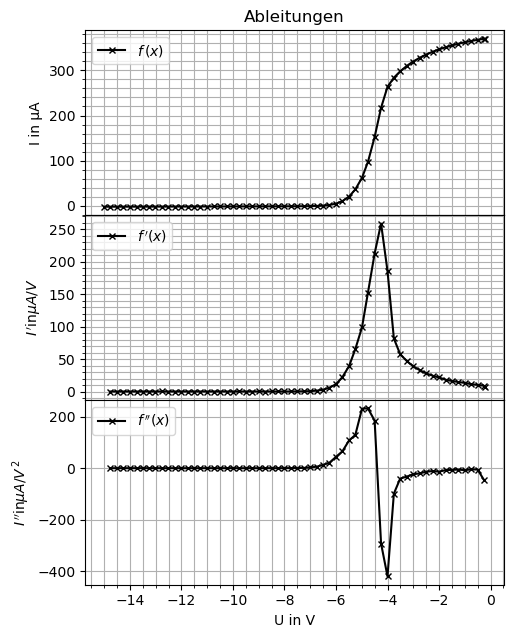

In [29]:
manlinie = np.loadtxt('../Messdaten/17112025_Langmuirsonden/AnodenkennlinieManuell_140V_60V_79mA6.dat', delimiter='\t', skiprows=1)

U = manlinie[:,0]
I = manlinie[:,1]*1e6 #in µA

dIdU = np.diff(I)/np.diff(U)
d2IdU2 = np.diff(dIdU)/np.diff(U[1:])


# plotten
fig, (ax1, ax2, ax3) = plt.subplots(3,1,sharex=True, gridspec_kw={'hspace':0.0}, figsize=(5.4,7.2)) #layout='constrained')
ax1.plot(U, I, 'x-k', ms=4, label=r'$f\,(x)$')
ax2.plot(U[1:], dIdU, 'x-k', ms=4, label=r"$f\,^\prime (x)$")
ax3.plot(U[1:-1], d2IdU2, 'x-k', ms=4, label=r"$f\,^{\prime\prime} (x)$")
ax3.set_xlabel('U in V')
ax1.set_ylabel('I in µA')
ax2.set_ylabel(r'$I\,^\prime \mathrm{ in } µA/V$')
ax3.set_ylabel(r'$I\,^{\prime\prime} \mathrm{ in } µA/V\,^2$')
ax1.set_title('Ableitungen')
ax1.legend(loc=2)
ax1.grid(which='both')
ax2.legend(loc=2)
ax2.grid(which='both')
ax3.legend(loc=2)
ax3.grid(which='both')
ax1.minorticks_on()
ax2.minorticks_on()
ax2.minorticks_on()
        # optional speichern
figname = file.split('.')[0]
        #plt.savefig(f'../Messdaten/17112025_Langmuirsonden/Bilder/{figname}.png')
plt.show()

Berechnung der Geschwindigkeitsverteilung 
mit $m_e^2/(e^3 2\pi A) = 3.6081\pm0.3649$
für $A = (8.9\pm0.9)mm^2$
und $2e/m_e = 3.51764e11$
und $U_pl = -4.25V$

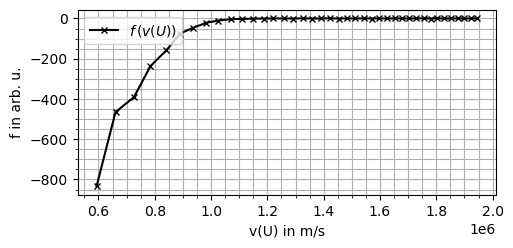

Mittlere Energie der Elektronen: 0.5110048264961282 MeV


In [ ]:
f = -3.6081*d2IdU2 

mask = np.where(U<-5)
v = np.sqrt(3.51764e11*(-4.25-U[mask]))

fig, (ax1) = plt.subplots(1,1,sharex=True, gridspec_kw={'hspace':0.0}, figsize=(5.4,2.4)) #layout='constrained')
ax1.plot(v, f[mask], 'x-k', ms=4, label=r'$f\,(v(U))$')
ax1.set_xlabel('v(U) in m/s')
ax1.set_ylabel('f in arb. u.')
ax1.legend(loc=2)
ax1.grid(which='both')
ax1.minorticks_on()
        # optional speichern
figname = file.split('.')[0]
        #plt.savefig(f'../Messdaten/17112025_Langmuirsonden/Bilder/{figname}.png')
plt.show()


print(f'Mittlere Energie der Elektronen: {((0.5*const.m_e*v**2+const.m_e*const.c**2)/const.e/1e6).mean()} MeV')

Da es sichtbare Probleme aufgrund der geringen Zahl an Datenpunkten gibt, versuchen wir es jetzt mit der automatischen Kennlinie bei dem höchsten Anodenstrom (für die beste Plasmacharakteristik)

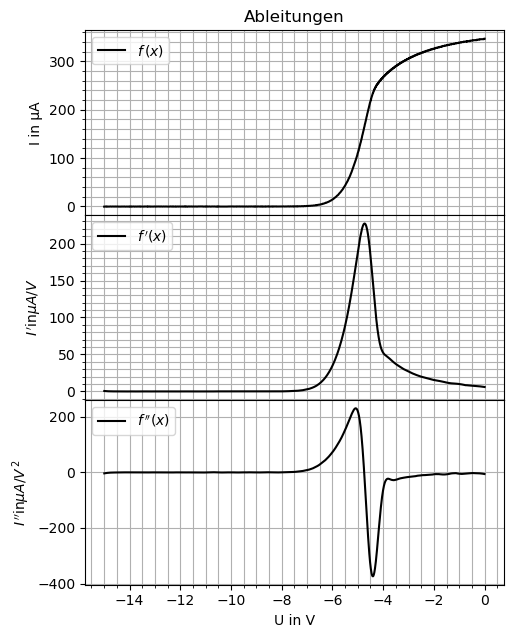

In [30]:
autolinie = np.loadtxt('../Messdaten/17112025_Langmuirsonden/Anodenkennlinie_132V_60V8_70mA9.dat', delimiter='\t', skiprows=3)

U = autolinie[:,0]
I = autolinie[:,1]*1e6 #in µA

window_length, polyorder = 120, 3

Ifil = savgol_filter(I, window_length, polyorder)

dIdU = np.diff(Ifil)/np.diff(U)

dIdUfil = savgol_filter(dIdU, window_length, polyorder)

d2IdU2 = np.diff(dIdUfil)/np.diff(U[1:])

d2IdU2fil = savgol_filter(d2IdU2, window_length, polyorder)


# plotten
fig, (ax1, ax2, ax3) = plt.subplots(3,1,sharex=True, gridspec_kw={'hspace':0.0}, figsize=(5.4,7.2)) #layout='constrained')
ax1.plot(U, I, '-k', ms=4, label=r'$f\,(x)$')
ax2.plot(U[1:], dIdUfil, '-k', ms=4, label=r"$f\,^\prime (x)$")
ax3.plot(U[1:-1], d2IdU2fil, '-k', ms=4, label=r"$f\,^{\prime\prime} (x)$")
ax3.set_xlabel('U in V')
ax1.set_ylabel('I in µA')
ax2.set_ylabel(r'$I\,^\prime \mathrm{ in } µA/V$')
ax3.set_ylabel(r'$I\,^{\prime\prime} \mathrm{ in } µA/V\,^2$')
ax1.set_title('Ableitungen')
ax1.legend(loc=2)
ax1.grid(which='both')
ax2.legend(loc=2)
ax2.grid(which='both')
ax3.legend(loc=2)
ax3.grid(which='both')
ax1.minorticks_on()
ax2.minorticks_on()
ax2.minorticks_on()
        # optional speichern
#figname = file.split('.')[4]
        #plt.savefig(f'../Messdaten/17112025_Langmuirsonden/Bilder/{figname}.png')
plt.show()

nächster Versuch jetzt mit der automatisch aufgenommenen Kennlinie die Geschwindigkeitsverteilung zu bestimmen

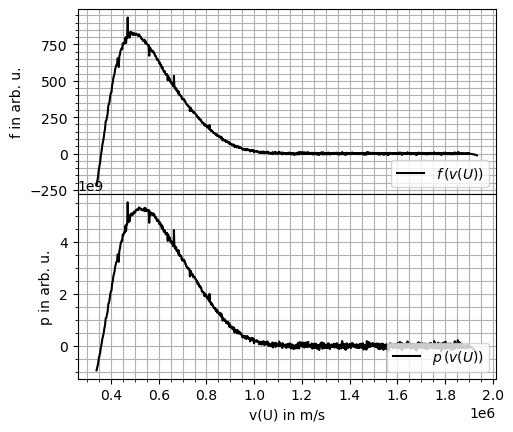

In [31]:
f = 3.6081*d2IdU2 # eigentlich gehört hier ein negatives Vorzeichen hin

mask = np.where(U<-4.7)
mask2 = np.where(f>0)


v = np.sqrt(3.51764e11*(-4.375-U[mask]))

pU = f[mask]*4*np.pi*v

fig, (ax1,ax2) = plt.subplots(2,1,sharex=True, gridspec_kw={'hspace':0.0}, figsize=(5.4,4.8)) #layout='constrained')
ax1.plot(v, f[mask], '-k', ms=4, label=r'$f\,(v(U))$')
ax1.set_xlabel('v(U) in m/s')
ax1.set_ylabel('f in arb. u.')
ax1.legend(loc=4)
ax1.grid(which='both')
ax1.minorticks_on()
ax2.plot(v, pU, '-k', ms=4, label=r'$p\,(v(U))$')
ax2.set_xlabel('v(U) in m/s')
ax2.set_ylabel('p in arb. u.')
ax2.legend(loc=4)
ax2.grid(which='both')
ax2.minorticks_on()
        # optional speichern
#figname = file.split('.')[4]
        #plt.savefig(f'../Messdaten/17112025_Langmuirsonden/Bilder/{figname}.png')
plt.show()


Fit einer modifizierten Maxwell-Verteilung an p

[6.98124685e+03 2.72713158e+15] 708586523018.5


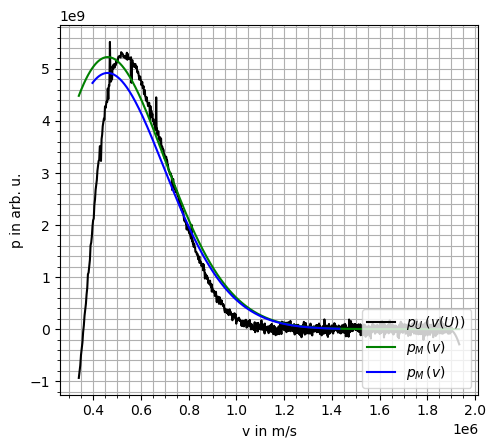

In [32]:
# Fitten
def res_maxwell(coeff, v, pU):
    Te, ne = coeff
    return (pU - (4*np.pi*v**2*ne*(const.m_e/(2*np.pi*const.k*Te))**(3/2)*np.exp(-const.m_e*v**2/(2*const.k*Te))))

guess_maxwell = [7000, 2.9e15]
TeI, neI = guess_maxwell

fit_start, fit_end = 800, -20

fit_maxwell = least_squares(res_maxwell, guess_maxwell, args=(v[fit_start:fit_end], pU[fit_start:fit_end]), method="trf")

Para_Maxwell = fit_maxwell.x
print(Para_Maxwell, fit_maxwell.optimality)
Te, ne = Para_Maxwell

pM = 4*np.pi*v**2*ne*(const.m_e/(2*np.pi*const.k*Te))**(3/2)*np.exp(-const.m_e*v**2/(2*const.k*Te))
pI = 4*np.pi*v**2*neI*(const.m_e/(2*np.pi*const.k*TeI))**(3/2)*np.exp(-const.m_e*v**2/(2*const.k*TeI))

fig, (ax1) = plt.subplots(1,1,sharex=True, gridspec_kw={'hspace':0.0}, figsize=(5.4,4.8)) #layout='constrained')
ax1.plot(v, pU, '-k', ms=4, label=r'$p_U\,(v(U))$')
ax1.plot(v, pI, '-g', ms=4, label=r'$p_M\,(v)$')
ax1.plot(v[fit_start:fit_end], pM[fit_start:fit_end], '-b', ms=4, label=r'$p_M\,(v)$')
ax1.set_xlabel('v in m/s')
ax1.set_ylabel('p in arb. u.')
ax1.legend(loc=4)
ax1.grid(which='both')
ax1.minorticks_on()

plt.show()

Versuch, die Geschwindigkeitsverteilung mit einer Druyvesteyn Verteilung zu fitten

[7523.41384284  585.53653472] 1298099965216.4375


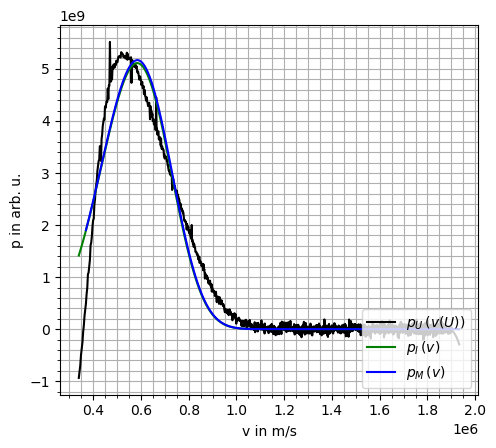

In [36]:
# Konstanten
m_e = 9.10938356e-31    # Elektronenmasse (kg)
k_B = 1.380649e-23      # Boltzmann-Konstante (J/K)

def druyvesteyn_fv(v, n_e, T_e):
    """
    Druyvesteyn-Geschwindigkeitsverteilung f_v(v; n_e, T_e)
    v   : Geschwindigkeit (m/s), kann Skalar oder Array sein
    n_e : Elektronendichte (m^-3)
    T_e : Elektronentemperatur (K)

    Rückgabe: f_v(v) so, dass ∫_0^∞ f_v dv = n_e
    """

    # b = m_e^2 / (9 k_B^2 T_e^2)
    b = m_e**2 / (9.0 * k_B**2 * T_e**2)

    # Normierungsfaktor: 4 * b^(3/4) / Gamma(3/4)
    pref = 4.0 * b**(3.0/4.0) / gamma(3.0/4.0)

    return 4*np.pi*v**2*n_e * pref * v**2 * np.exp(-b * v**4)

def res_druyve(coeff,v, pU):
    Te, ne = coeff
    return (pU - druyvesteyn_fv(v, ne, Te))

#f_clipped = f[mask]

guess_druyve = [7500, 580]
TeI, neI = guess_druyve

fit_start, fit_end = 0, -10

fit_druyve = least_squares(res_druyve, guess_druyve, args=(v[fit_start:fit_end], pU[fit_start:fit_end]), method="trf")

Para_Druyve = fit_druyve.x
print(Para_Druyve, fit_druyve.optimality)
Te, ne = Para_Druyve

pD = druyvesteyn_fv(v,ne,Te)
pI = druyvesteyn_fv(v,neI,TeI)

fig, (ax1) = plt.subplots(1,1,sharex=True, gridspec_kw={'hspace':0.0}, figsize=(5.4,4.8)) #layout='constrained')
ax1.plot(v, pU, '-k', ms=4, label=r'$p_U\,(v(U))$')
ax1.plot(v, pI, '-g', ms=4, label=r'$p_I\,(v)$')
ax1.plot(v[fit_start:fit_end], pD[fit_start:fit_end], '-b', ms=4, label=r'$p_M\,(v)$')
ax1.set_xlabel('v in m/s')
ax1.set_ylabel('p in arb. u.')
ax1.legend(loc=4)
ax1.grid(which='both')
ax1.minorticks_on()
